# 00 — Global-6 TCOCNNv3 Hyperparameter Optimization

Dieses Notebook optimiert das globale Quellmodell auf den sechs Quellsensoren. Von jedem Gerät wird ausschließlich Subsensor 0 verwendet. Sensor 7 ist vollständig von Training, Validierung und Modellauswahl ausgeschlossen.

Die Zielfunktion ist der sensorgetrennte UGM-RMSE auf der gepoolten Validierung der sechs Quellsensoren. Der beste Epoch-Checkpoint jedes Trials wird bewertet und der globale Gewinner inklusive Gewichten und Preprocessing gespeichert.

## Suchraum

Optimiert werden Filterzahl, Blocktiefe, Convolutions pro Block, Kanalwachstum, Kernel, Pooling-Schritt, Dense-Größe, Dropout, Startlernrate, Batchgröße und Residualverbindungen. Die Bayesian Search umfasst standardmäßig 24 Trials mit maximal 100 Epochen pro Trial.

In [1]:
from pathlib import Path
import json, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / 'Networks' / 'TCOCNNv3.py').exists())
SCRIPT = ROOT / 'Evaluation Seminar' / 'Day_04' / '00_Global6_Hyperparameter_Optimization.py'
OUTPUT = ROOT / 'artifacts' / 'seminar_day4_global6_hpo'
TRIALS = 24
EPOCHS = 100
SEED = 42

# False zeigt die bereits gespeicherten Ergebnisse sofort an.
# Auf True setzen, um die komplette HPO erneut auszuführen.
RUN_HPO = False

print('HPO-Skript:', SCRIPT)
print('Ergebnisordner:', OUTPUT)
print('Trials:', TRIALS, '| Epochen pro Trial:', EPOCHS, '| Seed:', SEED)

HPO-Skript: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Evaluation Seminar\Day_04\00_Global6_Hyperparameter_Optimization.py
Ergebnisordner: \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_global6_hpo
Trials: 24 | Epochen pro Trial: 100 | Seed: 42


In [2]:
if RUN_HPO:
    command = [sys.executable, '-u', str(SCRIPT), '--trials', str(TRIALS),
               '--epochs', str(EPOCHS), '--seed', str(SEED), '--output', str(OUTPUT)]
    subprocess.run(command, cwd=ROOT, check=True)
else:
    required = OUTPUT / 'best_hyperparameters.json'
    if not required.exists():
        raise FileNotFoundError('Keine HPO-Ergebnisse gefunden. RUN_HPO=True setzen.')
    print('Vorhandene vollständige HPO wird geladen; kein erneutes Training.')

Vorhandene vollständige HPO wird geladen; kein erneutes Training.


## Gewinner und Datengrenzen

Die folgenden Angaben stammen direkt aus der gespeicherten Gewinnerdatei. Das Leakage-Audit muss bestätigen, dass Sensor 7 nicht zur Modellauswahl verwendet wurde.

In [3]:
best = json.loads((OUTPUT / 'best_hyperparameters.json').read_text(encoding='utf-8'))
metadata = json.loads((OUTPUT / 'source_global6_hpo' / 'metadata.json').read_text(encoding='utf-8'))
assert best['test_or_target7_used'] is False
assert best['excluded_target'] not in best['sources']
assert metadata['params'] == best['params']

summary = {
    'selected_trial': best['selected_trial'],
    'best_epoch': best['best_epoch'],
    'source_validation_UGM_RMSE_ppb': best['best_validation_UGM_RMSE_ppb'],
    'parameter_count': metadata['parameter_count'],
    'sources': ', '.join(best['sources']),
    'excluded_target': best['excluded_target'],
    'input_shape': tuple(best['input_shape']),
}
try:
    import pandas as pd
    display(pd.DataFrame([summary]))
    display(pd.DataFrame([best['params']]).T.rename(columns={0: 'best_value'}))
except ImportError:
    print(json.dumps(summary, indent=2)); print(json.dumps(best['params'], indent=2))

{
  "selected_trial": 21,
  "best_epoch": 86,
  "source_validation_UGM_RMSE_ppb": 26.292286880580235,
  "parameter_count": 144097,
  "sources": "54118801, 54120037, 54120457, 54156953, 84746449, 84748697",
  "excluded_target": "84749569",
  "input_shape": [
    1,
    1440,
    1
  ]
}
{
  "n_filter": 16,
  "section_depth": 4,
  "convs_per_block": 3,
  "channel_growth": 8,
  "kernel": 15,
  "stride": 4,
  "num_neurons": 64,
  "drop_out": 0.3,
  "initial_learning_rate": 0.0001392233227508233,
  "batch_size": 64,
  "residual": false
}


## Alle Trials und beste Kandidaten

Die Tabelle ist nach Validierungsfehler sortiert. So bleiben neben dem Gewinner auch kompaktere Modelle mit nur geringfügig höherem Fehler sichtbar.

In [4]:
trials = json.loads((OUTPUT / 'trials.json').read_text(encoding='utf-8'))
valid = [row for row in trials if row.get('status') == 'ok']
print(f'Erfolgreiche Trials: {len(valid)}/{len(trials)}')
columns = ['trial', 'UGM_RMSE_ppb', 'UGM_R2', 'best_epoch', 'parameter_count',
           'n_filter', 'section_depth', 'convs_per_block', 'channel_growth',
           'kernel', 'stride', 'num_neurons', 'drop_out',
           'initial_learning_rate', 'batch_size', 'residual', 'seconds']
if 'pd' in globals():
    trial_table = pd.DataFrame(valid).sort_values('UGM_RMSE_ppb')
    display(trial_table[columns].head(12))
else:
    print(json.dumps(sorted(valid, key=lambda row: row['UGM_RMSE_ppb'])[:12], indent=2))

Erfolgreiche Trials: 24/24
[
  {
    "trial": 21,
    "n_filter": 16,
    "section_depth": 4,
    "convs_per_block": 3,
    "channel_growth": 8,
    "kernel": 15,
    "stride": 4,
    "num_neurons": 64,
    "drop_out": 0.3,
    "initial_learning_rate": 0.0001392233227508233,
    "batch_size": 64,
    "residual": false,
    "UGM_RMSE_ppb": 26.292286880580235,
    "UGM_R2": 0.8868248907729894,
    "UGMs": 114,
    "best_epoch": 86,
    "parameter_count": 144097,
    "seconds": 118.35158769998816,
    "status": "ok"
  },
  {
    "trial": 19,
    "n_filter": 16,
    "section_depth": 4,
    "convs_per_block": 3,
    "channel_growth": 8,
    "kernel": 15,
    "stride": 4,
    "num_neurons": 64,
    "drop_out": 0.3,
    "initial_learning_rate": 0.0001,
    "batch_size": 64,
    "residual": false,
    "UGM_RMSE_ppb": 26.45403969364104,
    "UGM_R2": 0.8854280778019845,
    "UGMs": 114,
    "best_epoch": 86,
    "parameter_count": 144097,
    "seconds": 120.74201610000455,
    "status": "ok"
  

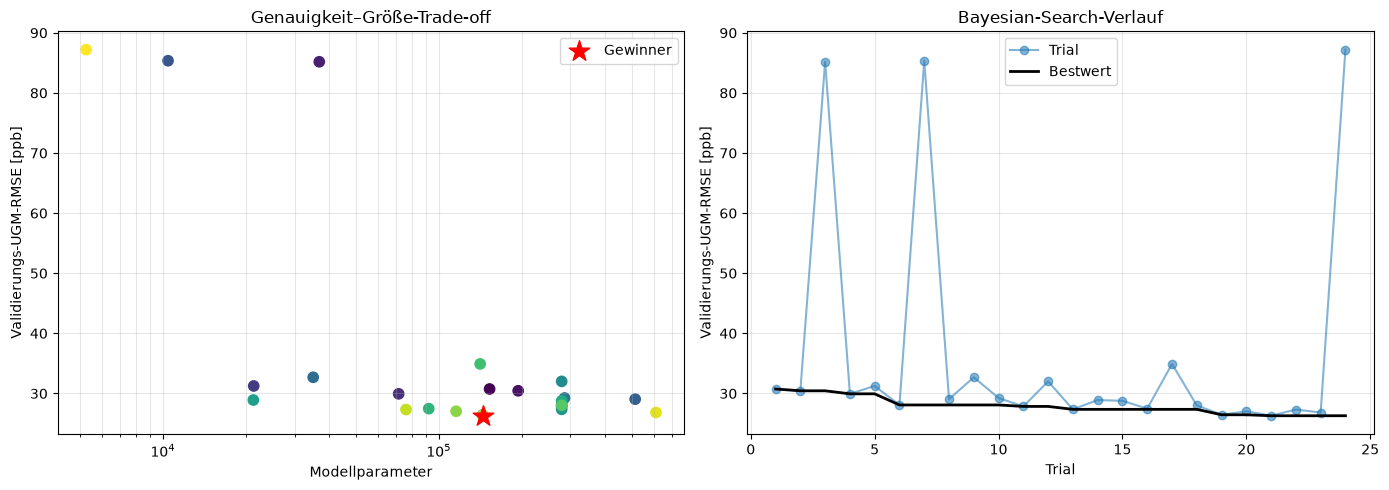

In [5]:
scores = np.asarray([row['UGM_RMSE_ppb'] for row in valid])
counts = np.asarray([row['parameter_count'] for row in valid])
trial_ids = np.asarray([row['trial'] for row in valid])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(counts, scores, c=trial_ids, cmap='viridis', s=55)
axes[0].scatter(metadata['parameter_count'], best['best_validation_UGM_RMSE_ppb'],
                marker='*', s=240, color='red', label='Gewinner')
axes[0].set(xscale='log', xlabel='Modellparameter', ylabel='Validierungs-UGM-RMSE [ppb]',
            title='Genauigkeit–Größe-Trade-off')
axes[0].legend()
axes[1].plot(trial_ids, scores, marker='o', alpha=.55, label='Trial')
axes[1].plot(trial_ids, np.minimum.accumulate(scores), color='black', lw=2, label='Bestwert')
axes[1].set(xlabel='Trial', ylabel='Validierungs-UGM-RMSE [ppb]', title='Bayesian-Search-Verlauf')
for axis in axes: axis.grid(True, which='both', alpha=.3)
axes[1].legend(); fig.tight_layout(); plt.show()

## Gespeicherte HPO- und Lernkurven

Die linke Kurve zeigt alle HPO-Trials und den jeweils besten Zwischenstand. Die rechte Kurve zeigt Train und Validierung des gespeicherten Gewinnertrials.

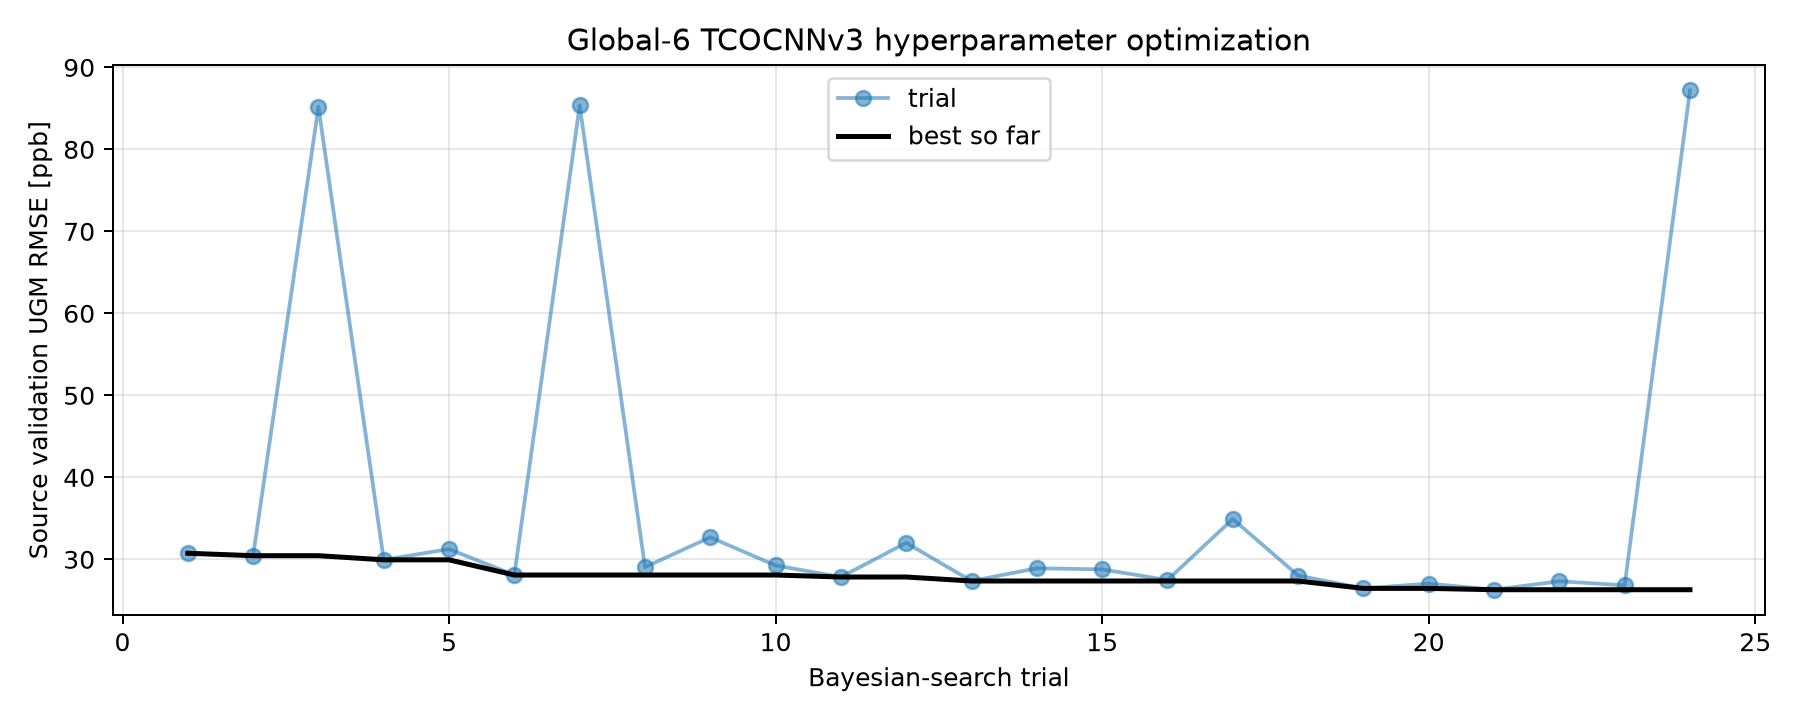

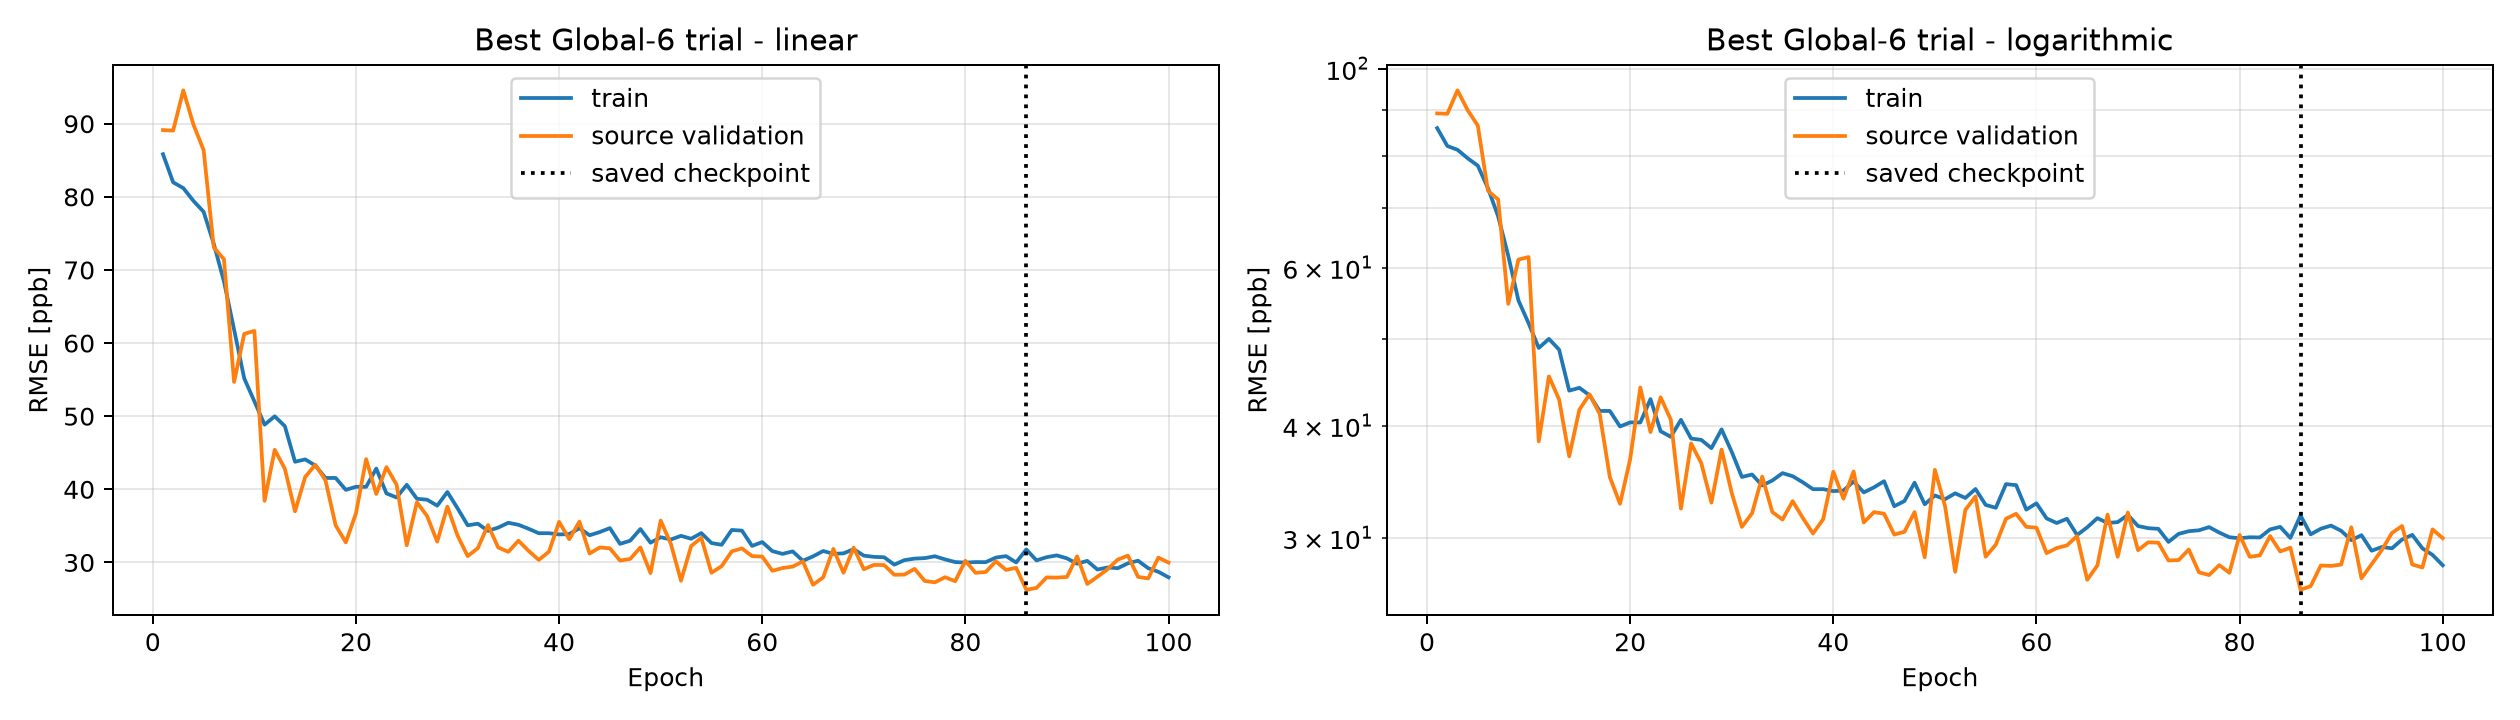

In [6]:
display(Image(filename=str(OUTPUT / 'hpo_progress.png')))
display(Image(filename=str(OUTPUT / 'best_training_curve.png')))

## Gespeichertes Modell

Der Checkpoint enthält die gelernten Gewichte. Die JSON-Dateien enthalten Architektur, Trainingseinstellungen, Auswahlmetrik und Auditinformationen. Notebook 01 verwendet anschließend automatisch `best_hyperparameters.json`.

In [7]:
artifacts = [OUTPUT / 'best_hyperparameters.json', OUTPUT / 'trials.json',
             OUTPUT / 'source_global6_hpo' / 'weights.pt',
             OUTPUT / 'source_global6_hpo' / 'preprocessing.npz',
             OUTPUT / 'source_global6_hpo' / 'metadata.json']
for path in artifacts:
    if not path.exists(): raise FileNotFoundError(path)
    print(f'{path.name:30s} {path.stat().st_size:>10,d} Bytes  {path}')

best_hyperparameters.json           2,001 Bytes  \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_global6_hpo\best_hyperparameters.json
trials.json                        12,410 Bytes  \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_global6_hpo\trials.json
weights.pt                        605,147 Bytes  \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_global6_hpo\source_global6_hpo\weights.pt
preprocessing.npz                   7,040 Bytes  \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_global6_hpo\source_global6_hpo\preprocessing.npz
metadata.json                         763 Bytes  \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_global6_hpo\source_global6_hpo\metadata.json
